We are going to run the same model but this time we will perform a much more realistic set of experiments

In [333]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.optimize import minimize


Again, we're going to start by defining the workflow of the model rather than beginning with the data. However, rather than defining a loose set of functions this time we are going to use what is known as a _class_. This is a python object with a specific set of fucntions that are associated with it already. It is a much tidier way of keeping all our model functions in one place.

classes come with a few special function which we can define as well, but for now the important one for us to focus on is `__init__` _Note: double underscores, like_ `_ _ init _ _`. This is a function which will be run when we first call the class in our script and is where we can put any setup. We should use this to set out the order that the functions in our class will be run in, and any kew word arguments that they might need to use.

The other thing is that the class has this concept of `self`, which is our way of telling python to look for the function or variable inside of the class rather than outside. If we want to define and use something say x only within the class, it becomes self.x instead which tells python where it lives. We need to pass self to any functions that we define in the class if we want to use self inside these function

Lets define our class

In [334]:
class BaselineModel():
    def __init__(self):
        self.functions = {
            'calculate_emissions':self.calc_emissions,
            'offset_cost_gbp_per_year':self.calc_offset_cost,
            'plot':self.plot_element_over_time
        }
        self.kwargs = {'plot':dict(dim = 'fuel',
                                   key = 'offset_cost_gbp_per_year',
                                   label = 'vehicle')}
        
        self.order = ['calculate_emissions',
                 'offset_cost_gbp_per_year',
                 'plot']
        
    def calc_emissions(self, ds):
        ds['emissions_tons_per_year'] = ds['emissions_tons_per_kwh'] * ds['power_kwh']
        return ds
    
    def calc_offset_cost(self, ds):
        ds['offset_cost_gbp_per_year'] = ds['offset_base_cost_gbp_per_ton'] * ds['emissions_tons_per_year']
        return ds
    
    def plot_element_over_time(self, ds, dim, key, label):
        """
        Plot a stacked area chart of a dataset aggregated over a dimension.

        Parameters:
            ds : xarray.Dataset
                Dataset
            dim : str or list[str]
                Dimension(s) to sum over before plotting.
            key : str
                Name of the data variable to extract after summing. Can't be in summing list!
            label : str
                Coordinate used to label each stacked area segment. Cant be in summing list!

        Displays a matplotlib stackplot of the aggregated values over time.
        """
        ds_y = ds.sum(dim=dim)[key]
        plt.stackplot(ds_y['year'],
                    ds_y.values.T,
                    labels=ds_y[label].values
                    )
        plt.legend()
        return ds #every step now needs to return the ds so we can chain them in any order
    
    def compute(self, data):
        for step in self.order:
            step_func = self.functions[step]
            step_kwargs = self.kwargs.get(step, {}) #if there are key word arguments get them, if there are none get an empty dictionary instead
            data = step_func(data,**step_kwargs) # **dict will extract the dict into the function as if I had defined all the kwargs here manually
        return data.copy(deep=True)

we have also added a compute function. This reads the name of the steps in order from self.order, finds the function with that name in self.functions, and then executes that function on the data

this is part of our data loading and doesnt need to be in the function

In [335]:
def calc_carbon_cost(year):
    cost = 10 + ((year-2026)**0.6)
    return cost


lets load our data and then we can try this out

## Data Loading

In [336]:
years = np.arange(2026,2030,1)

power_kwh = (pd.read_csv(r"data\vehicles.csv")
            .set_index(["vehicle", "fuel"])
            .to_xarray())  # power_kwh becomes a data variable

offset_base_cost_gbp_per_ton = xr.DataArray(
    calc_carbon_cost(years),
    coords={"year": years},
    dims=("year",),
    name="offset_base_cost_gbp_per_ton",
)

ds = power_kwh.merge(offset_base_cost_gbp_per_ton)

ds['emissions_tons_per_kwh'] = (pd.read_csv(r"data\fuel.csv")
                .set_index("fuel")["emissions_tons_per_kwh"]
                .to_xarray())

ds

<xarray.Dataset> Size: 168B
Dimensions:                       (vehicle: 3, fuel: 2, year: 4)
Coordinates:
  * vehicle                       (vehicle) object 24B 'generator' ... 'tractor'
  * fuel                          (fuel) object 16B 'diesel' 'petrol'
  * year                          (year) int64 32B 2026 2027 2028 2029
Data variables:
    power_kwh                     (vehicle, fuel) float64 48B 2.3e+03 ... nan
    offset_base_cost_gbp_per_ton  (year) float64 32B 10.0 11.0 11.52 11.93
    emissions_tons_per_kwh        (fuel) float64 16B 0.35 0.25

now we can do the experiment as set out above. We create an instance of our model class

In [337]:
model = BaselineModel()
model


we can see the steps inside the model

In [338]:
model.functions

{'calculate_emissions': <bound method BaselineModel.calc_emissions of <__main__.BaselineModel object at 0x000001AC02BAB8C0>>,
 'offset_cost_gbp_per_year': <bound method BaselineModel.calc_offset_cost of <__main__.BaselineModel object at 0x000001AC02BAB8C0>>,
 'plot': <bound method BaselineModel.plot_element_over_time of <__main__.BaselineModel object at 0x000001AC02BAB8C0>>}

and the order they will be executed in

In [339]:
model.order

['calculate_emissions', 'offset_cost_gbp_per_year', 'plot']

so lets pass the data to the model and run it

<xarray.Dataset> Size: 408B
Dimensions:                       (vehicle: 3, fuel: 2, year: 4)
Coordinates:
  * vehicle                       (vehicle) object 24B 'generator' ... 'tractor'
  * fuel                          (fuel) object 16B 'diesel' 'petrol'
  * year                          (year) int64 32B 2026 2027 2028 2029
Data variables:
    power_kwh                     (vehicle, fuel) float64 48B 2.3e+03 ... nan
    offset_base_cost_gbp_per_ton  (year) float64 32B 10.0 11.0 11.52 11.93
    emissions_tons_per_kwh        (fuel) float64 16B 0.35 0.25
    emissions_tons_per_year       (fuel, vehicle) float64 48B 805.0 nan ... nan
    offset_cost_gbp_per_year      (year, fuel, vehicle) float64 192B 8.05e+03...

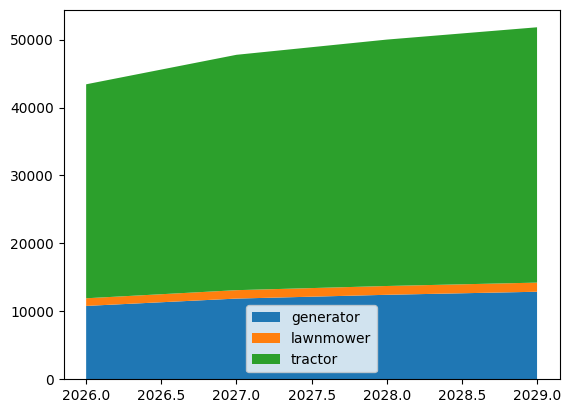

In [340]:
baseline_data  = model.compute(ds)
baseline_data

we can also just use functions from within the class directly as we would normally such as

<xarray.Dataset> Size: 408B
Dimensions:                       (vehicle: 3, fuel: 2, year: 4)
Coordinates:
  * vehicle                       (vehicle) object 24B 'generator' ... 'tractor'
  * fuel                          (fuel) object 16B 'diesel' 'petrol'
  * year                          (year) int64 32B 2026 2027 2028 2029
Data variables:
    power_kwh                     (vehicle, fuel) float64 48B 2.3e+03 ... nan
    offset_base_cost_gbp_per_ton  (year) float64 32B 10.0 11.0 11.52 11.93
    emissions_tons_per_kwh        (fuel) float64 16B 0.35 0.25
    emissions_tons_per_year       (fuel, vehicle) float64 48B 805.0 nan ... nan
    offset_cost_gbp_per_year      (year, fuel, vehicle) float64 192B 8.05e+03...

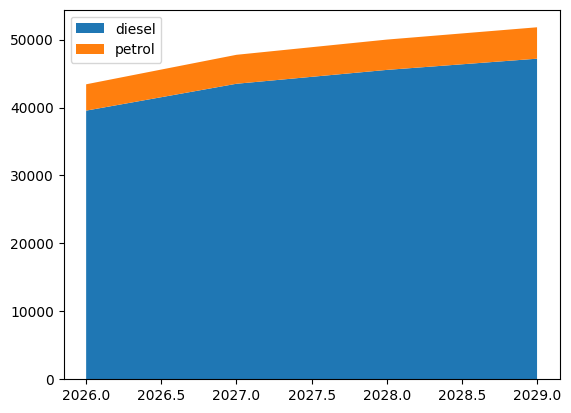

In [341]:
model.plot_element_over_time(
    baseline_data,
    'vehicle',
    'offset_cost_gbp_per_year',
    'fuel'
)

this time, say we want to minimise impact to already relatively low emissions vehicles by applying a specific discount $x$ to the first $y$ tons of emmision per archetype/fuel pair such that the cost of lawnmower operation is reduced by exactly 80% yearly

First we have to change the relevant function, this time exposing the relevant hyperparameters

In [342]:
def calc_offset_cost(ds, x, y):
    # first y tons
    discounted_tons = np.minimum(ds['emissions_tons_per_year'], y)
    # overflow
    full_price_tons = np.maximum(ds['emissions_tons_per_year'] - y, 0)

    ds['offset_cost_gbp_per_year'] = ds['offset_base_cost_gbp_per_ton'] * ((1-x) * discounted_tons + full_price_tons)
    return ds

then we can replace the current function in the model with this new modified one

In [343]:
modified_model = BaselineModel()
modified_model.functions['offset_cost_gbp_per_year'] = calc_offset_cost

this means we can run the experiment with lots of different hyperparametrs very easily.

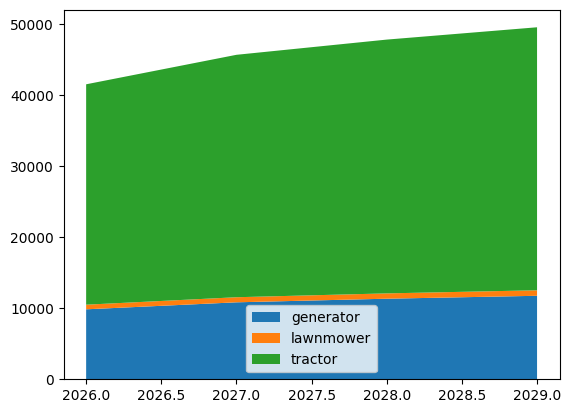

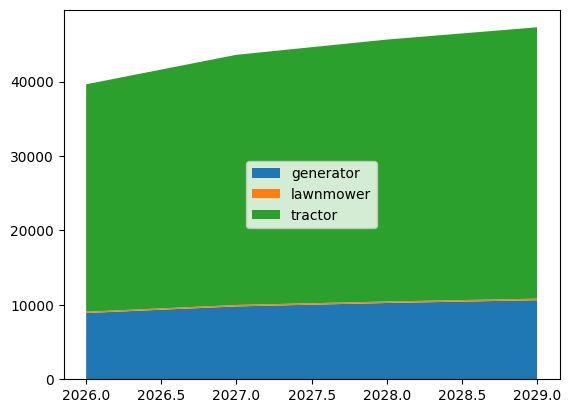

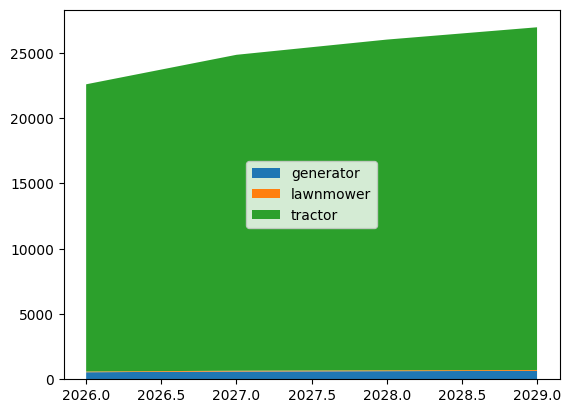

In [344]:
for y in [50,100,1000]:
    plt.figure()
    
    modified_model.kwargs['offset_cost_gbp_per_year'] = dict(x=0.95, y=y)
    modified_model.compute(ds)

now lets try and optimise for the solution that we need.

_"say we want to minimise impact to already relatively low emissions vehicles by applying a specific discount $x$ to the first $y$ tons of emmision per archetype/fuel pair such that the cost of lawnmower operation is reduced by exactly 80% yearly"_

so if the price of lawnmower acording to the modified function is given by $C^\prime = f(x,y)$, and $C$ according to the baseline:


$$
\begin{aligned}
f(x,y) &= 0.2C \\
\frac{f(x,y) - C}{C} &= -0.8 \\
\end{aligned}
$$


we can first define a helper function to the end of the model that will just output $\frac{f(x,y) - C}{C}$

In [345]:
def cost_function(ds, baseline_ds):
    return ((ds['offset_cost_gbp_per_year'] - baseline_ds['offset_cost_gbp_per_year']) / baseline_ds['offset_cost_gbp_per_year']
            ).sel(dict(fuel='petrol',vehicle='lawnmower')
            ).mean(dim='year')

then we can add this into the model

In [346]:
modified_model.functions['cost_helper'] = cost_function
modified_model.kwargs['cost_helper'] = dict(baseline_ds=baseline_data)
modified_model.order = ['calculate_emissions',
                 'offset_cost_gbp_per_year',
                 'cost_helper'] # we will need to iterate over this model, so for now lets remove the plotting step

let's run this model a few times again changing y

In [347]:
for y in np.arange(10,200,20):
    modified_model.kwargs['offset_cost_gbp_per_year'] = dict(x=0.95, y=y)
    print(f"{y}: {modified_model.compute(ds).values}")

10: -0.08444444444444445
30: -0.25333333333333335
50: -0.4222222222222222
70: -0.5911111111111111
90: -0.76
110: -0.9288888888888889
130: -0.95
150: -0.95
170: -0.95
190: -0.95


this is good, but we also need to think about the effect of changing x as well. Rather than doing this by hand let's feed this into an optimiser. 

In [348]:
target = -0.8

def objective(params):
    x, y = params
    modified_model.kwargs['offset_cost_gbp_per_year'] = dict(x=x, y=y)
    out = modified_model.compute(ds).values
    return abs(out - target)

#starting guess - something reasonable ish
x0 = np.array([0.95, 50])

#bounds x must be in [0, 1], y in [0, +inf)
bounds = [(0.0, 1.0), (0.0, None)]


res = minimize(
    objective,
    x0,
    bounds=bounds,
)

x_sol, y_sol = res.x
sol = np.nanmean(modified_model.compute(ds).values)*-100

print(f"Optimised x = {x_sol:.8f}, y = {y_sol:.8f}")
print(f"solution = {sol:.10f}%")

print(
    f"\n\nBy applying a discount of {(x_sol)*100:.1f}% to the first {y_sol:.2f} tons of emissions for each archetype–fuel pair,\nwe can minimise the impact on already low‑emitting vehicles while ensuring that the annual operating\ncost of lawnmower equipment is reduced by {sol:.10f}%"
)

Optimised x = 0.99901594, y = 90.08865228
solution = 80.0000000052%


By applying a discount of 99.9% to the first 90.09 tons of emissions for each archetype–fuel pair,
we can minimise the impact on already low‑emitting vehicles while ensuring that the annual operating
cost of lawnmower equipment is reduced by 80.0000000052%


now we can rerun the experiment one final time with our solution values

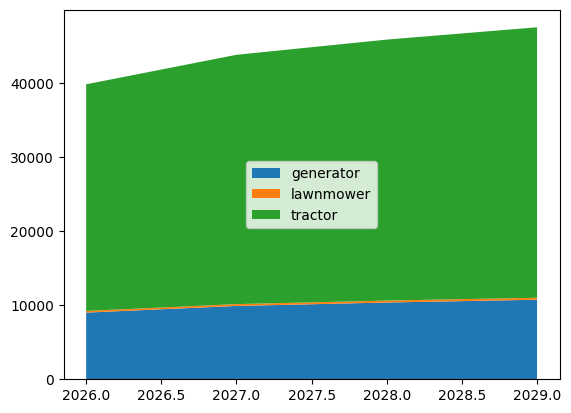

In [349]:
optimised_model = BaselineModel()
optimised_model.functions['offset_cost_gbp_per_year'] = calc_offset_cost
optimised_model.kwargs['offset_cost_gbp_per_year'] = dict(x=x_sol, y=y_sol)
optimised_data = optimised_model.compute(ds)

and plot the yearly cost reduction for each vehicle fuel pair as a percentage.

 (this is technically the yearly average, but as there is no yearly component to calc offset cost then there this is also just the actual yearly percentage cost as percentage cost does not vary with time)

In [350]:
frac_residual = (optimised_data['offset_cost_gbp_per_year'] - baseline_data['offset_cost_gbp_per_year']) / baseline_data['offset_cost_gbp_per_year']

# aggregate over time
all_time = frac_residual.mean(dim='year') * -100  # percentage

# stack to one dimension (pair = vehicle,fuel)
fuel_vehicle_pairs = all_time.stack(pair=('vehicle', 'fuel'))

fuel_vehicle_pairs

<xarray.DataArray 'offset_cost_gbp_per_year' (pair: 6)> Size: 48B
array([11.18012422, 32.72727273,         nan, 80.        ,  2.85714286,
               nan])
Coordinates:
  * pair     (pair) object 48B MultiIndex
  * vehicle  (pair) object 48B 'generator' 'generator' ... 'tractor' 'tractor'
  * fuel     (pair) object 48B 'diesel' 'petrol' 'diesel' ... 'diesel' 'petrol'

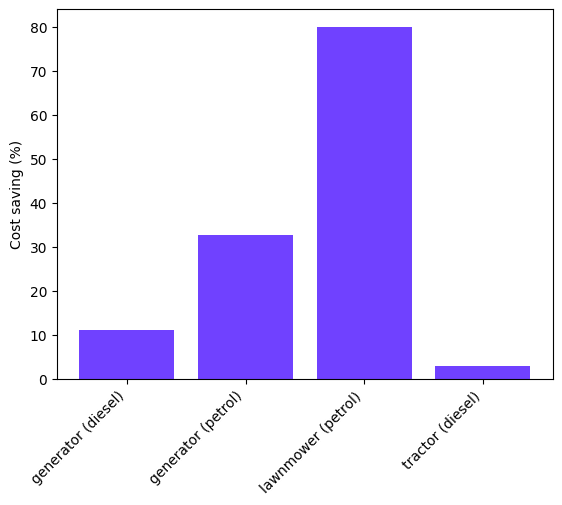

In [351]:
# drop pairs which dont exist aka petrol tractors etc
agg_stacked = fuel_vehicle_pairs[np.isfinite(fuel_vehicle_pairs.values)]

# make readable strings for plot labels
x_labels = [f"{v} ({f})" for (v, f) in agg_stacked['pair'].values]

plt.bar(x_labels, agg_stacked.values, color = "#7041FF")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Cost saving (%)')
plt.show()